# 02 - Simple RUL Baseline

We define end of life (EOL) at the first **1.4 Ah** capacity crossing, then train on B0005 and B0006 and test on unseen B0018. Capacity creates the target but is not a model input.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
from sklearn.linear_model import LinearRegression

plt.style.use("seaborn-v0_8-whitegrid")
DATA_ROOT = Path(os.environ.get("NASA_BATTERY_DATA", "/home/aymen/data/nasa-battery"))
COHORT = DATA_ROOT / "1. BatteryAgingARC-FY08Q4"
BATTERIES = ["B0005", "B0006", "B0007", "B0018"]
EOL_AH = 1.4
if not COHORT.exists():
    raise FileNotFoundError(f"Dataset folder not found: {COHORT}")

## One row per discharge cycle

We keep only simple voltage, current, and temperature summaries.

In [2]:
def battery_rows(battery_id):
    path = COHORT / f"{battery_id}.mat"
    raw = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    cycles = np.atleast_1d(raw[battery_id].cycle)
    rows = []
    for cycle_index, operation in enumerate(c for c in cycles if c.type == "discharge"):
        d = operation.data
        voltage = np.asarray(d.Voltage_measured).reshape(-1)
        current = np.asarray(d.Current_measured).reshape(-1)
        temperature = np.asarray(d.Temperature_measured).reshape(-1)
        rows.append({
            "battery_id": battery_id, "cycle": cycle_index,
            "capacity_ah": float(np.asarray(d.Capacity).reshape(-1)[0]),
            "voltage_min": voltage.min(), "voltage_mean": voltage.mean(),
            "current_mean": current.mean(),
            "temperature_mean": temperature.mean(),
            "temperature_max": temperature.max(),
        })
    return rows

df = pd.DataFrame([row for battery in BATTERIES for row in battery_rows(battery)])
print(f"Discharge rows: {len(df)}")
df.head()

Discharge rows: 636


,battery_id,cycle,capacity_ah,voltage_min,voltage_mean,current_mean,temperature_mean,temperature_max
0,B0005,0,1.856487,2.612467,3.529829,-1.818702,32.572328,38.982181
1,B0005,1,1.846327,2.587209,3.537320,-1.817560,32.725235,39.033398
2,B0005,2,1.835349,2.651917,3.543737,-1.816487,32.642862,38.818797
3,B0005,3,1.835263,2.592948,3.543666,-1.825589,32.514876,38.762305
4,B0005,4,1.834646,2.547420,3.542343,-1.826114,32.382349,38.665393


## Define EOL and RUL

EOL is the first cycle at or below 1.4 Ah. Before EOL, RUL is simply EOL cycle minus current cycle. A battery that never crosses is censored.

In [3]:
eol_rows = []
for battery_id, part in df.groupby("battery_id"):
    crossing = part.loc[part["capacity_ah"] <= EOL_AH, "cycle"]
    eol = int(crossing.iloc[0]) if len(crossing) else np.nan
    eol_rows.append({
        "battery_id": battery_id, "observed_cycles": len(part),
        "eol_cycle": eol, "status": "observed" if len(crossing) else "censored",
    })

eol_table = pd.DataFrame(eol_rows)
display(eol_table)
df = df.merge(eol_table[["battery_id", "eol_cycle"]], on="battery_id")
df["rul"] = df["eol_cycle"] - df["cycle"]
model_df = df[df["rul"].notna() & (df["rul"] >= 0)].copy()

# Show the final labeled rows used for ordinary RUL regression.
display(model_df[["battery_id", "cycle", "capacity_ah", "eol_cycle", "rul"]].head(10))

,battery_id,observed_cycles,eol_cycle,status
0,B0005,168,124.0,observed
1,B0006,168,108.0,observed
2,B0007,168,NaN,censored
3,B0018,132,96.0,observed


,battery_id,cycle,capacity_ah,eol_cycle,rul
0,B0005,0,1.856487,124.0,124.0
1,B0005,1,1.846327,124.0,123.0
2,B0005,2,1.835349,124.0,122.0
3,B0005,3,1.835263,124.0,121.0
4,B0005,4,1.834646,124.0,120.0
5,B0005,5,1.835662,124.0,119.0
6,B0005,6,1.835146,124.0,118.0
7,B0005,7,1.825757,124.0,117.0
8,B0005,8,1.824774,124.0,116.0
9,B0005,9,1.824613,124.0,115.0


Rq : B0005 reaches EOL at cycle 124, B0006 at cycle 108, and B0018 at cycle 96. The new RUL column counts down to zero: for example, a row at cycle 20 for B0005 has an RUL of 104 cycles (124 - 20). B0007 has no RUL values here because it never reaches the 1.4 Ah threshold.


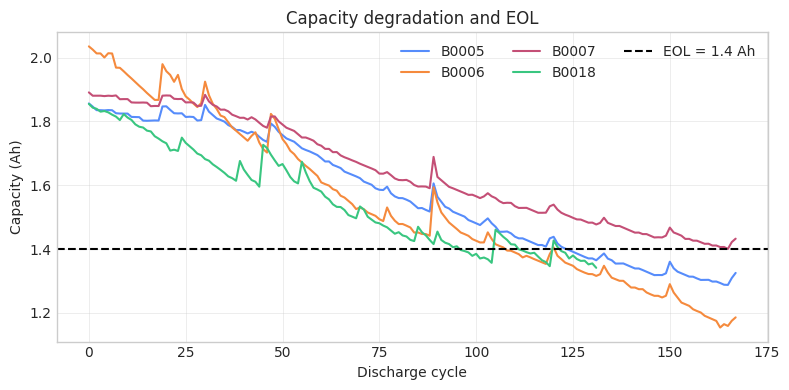

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for battery_id, part in df.groupby("battery_id"):
    ax.plot(part["cycle"], part["capacity_ah"], label=battery_id)
ax.axhline(EOL_AH, color="black", linestyle="--", label="EOL = 1.4 Ah")
ax.set(title="Capacity degradation and EOL", xlabel="Discharge cycle", ylabel="Capacity (Ah)")
ax.legend(ncol=3)
plt.tight_layout()

Rq
The batteries age differently. B0007 does not reach 1.4 Ah, so it is censored and is not given an invented RUL label.

## Simple linear regression

Each row represents one discharge cycle. We put all cycles from B0005 and B0006 in the training set + all cycles from B0018 in the test set. The model therefore predicts a battery it did not see during training.

The model inputs are only voltage, current, and temperature summaries. Capacity and EOL are used to calculate the answer we want to predict (RUL), so giving them to the model would reveal the answer.

- **Inputs (X):** voltage, current, and temperature summaries.
- **Target (y):** RUL.
- **Capacity and EOL:** used to build RUL, but not used as model inputs.

We use a standard linear regression: it learns one coefficient for each input and combines them to predict RUL.


In [5]:
FEATURES = [
    "voltage_mean",
    "current_mean",
    "temperature_mean",
]
train = model_df[model_df["battery_id"].isin(["B0005", "B0006"])]
test = model_df[model_df["battery_id"] == "B0018"].copy()

# Fit a simple linear regression model.
model = LinearRegression()
model.fit(train[FEATURES], train["rul"])
test["predicted_rul"] = model.predict(test[FEATURES])

errors = test["predicted_rul"] - test["rul"]
mae = errors.abs().mean()
rmse = np.sqrt(np.mean(errors ** 2))
print("Train: B0005, B0006")
print("Test:  B0018")
print(f"MAE:  {mae:.1f} cycles")
print(f"RMSE: {rmse:.1f} cycles")

Train: B0005, B0006
Test:  B0018
MAE:  29.6 cycles
RMSE: 33.2 cycles


Rq :On the unseen B0018 battery, the model has an **MAE of 29.6 cycles**. This means its predictions are about 30 cycles away from the true RUL on average. The RMSE is slightly higher at 33.2 cycles, showing that some errors are larger. The result is not accurate enough for real use, but it is an honest first baseline because B0018 was not used during training.


## Example predictions during battery life

Instead of looking only at one average error, we can inspect the prediction near the beginning, middle, and end of B0018's life.


In [6]:
# Select three easy-to-explain moments from the test battery.
positions = [0, len(test) // 2, len(test) - 1]
examples = test.iloc[positions][["cycle", "rul", "predicted_rul"]].copy()
examples["error"] = examples["predicted_rul"] - examples["rul"]
examples["life_stage"] = ["early", "middle", "near EOL"]
examples = examples[["life_stage", "cycle", "rul", "predicted_rul", "error"]]
examples.round(1)


,life_stage,cycle,rul,predicted_rul,error
504,early,0,96.0,76.6,-19.4
552,middle,48,48.0,88.3,40.3
600,near EOL,96,0.0,47.9,47.9


Rq : Early in B0018's life, the model predicts 76.6 remaining cycles instead of 96, so it underestimates RUL by 19.4 cycles. In the middle it overestimates RUL by 40.3 cycles. At the actual EOL, it still predicts 47.9 cycles remaining. This shows that the simple linear model does not follow B0018's degradation well, especially near EOL.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(test["cycle"], test["rul"], label="True RUL", linewidth=2)
ax.plot(test["cycle"], test["predicted_rul"], label="Predicted RUL")
ax.set(
    title="Linear regression predictions on unseen B0018",
    xlabel="Discharge cycle",
    ylabel="RUL (cycles)",
)
ax.legend()
plt.tight_layout()


The baseline proves that we can construct RUL labels, avoid mixing batteries between training and testing, and evaluate a model on a new battery. Its errors also show that three cycle-level means and a linear relationship are not sufficient for accurate RUL prediction.
